In [1]:
import pandas as pd

# Đường dẫn chính xác tới file CSV của bạn
duong_dan = r'D:\FOR PORTFOLIO ON GITHUB\python\netflix_titles.csv'

# Đọc file dữ liệu Netflix
df = pd.read_csv(duong_dan)

# In thử 3 dòng đầu tiên ra màn hình (trong Jupyter chỉ cần gọi tên biến là nó tự in thành bảng đẹp)
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [4]:
# 1. Nhap cac thu vien
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 2. Doc file du lieu
df = pd.read_csv(r"D:\FOR PORTFOLIO ON GITHUB\python\netflix_titles.csv")
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [5]:
#DATA CLEANING
#1. Kiem tra xem moi cot dang bi thieu bao nhieu du lieu
print("---Tinh trang du lieu trong---")
print(df.isna().sum())
#2. Dien 'Unknown' cho nhuwng cho bi miss du lieu
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
#3. Xoa nhung dong bi khuyet trong 'date_added'
df = df.dropna(subset=['date_added'])
print("\n--- CLEAN DATA---")

---Tinh trang du lieu trong---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

--- CLEAN DATA---


In [7]:
#1. So sanh so luong phim dien anh (Movie) va phim bo (TV Show)
loai_phim = df['type'].value_counts()
print("---Xu huong thay doi theo thoi gian---")
print(loai_phim)
#2. Top 5 quoc gia san xuat nhieu noi dung nhat
top_quoc_gia = df['country'].value_counts().head(5)
print("\n---TOP 5---")
print(top_quoc_gia)

---Xu huong thay doi theo thoi gian---
type
Movie      6131
TV Show    2666
Name: count, dtype: int64

---TOP 5---
country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Name: count, dtype: int64


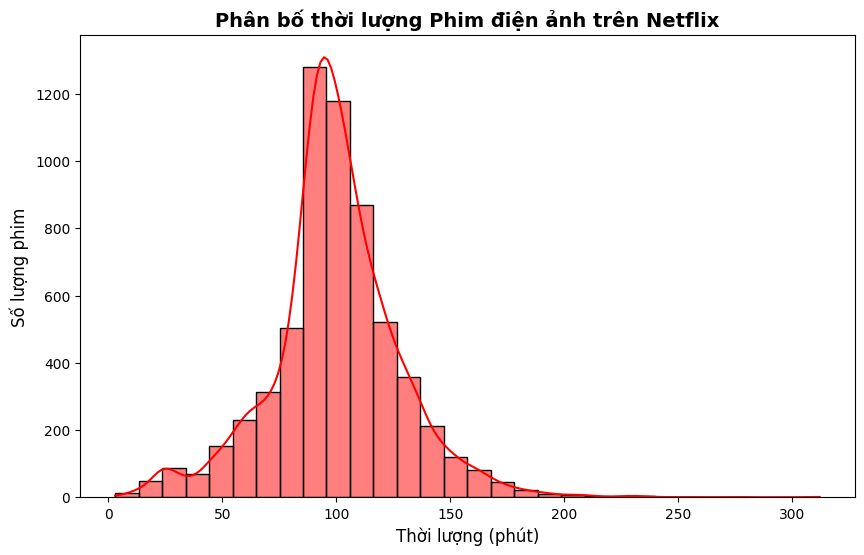

In [11]:
# Truc qua hoa du lieu
# 1.Loc mot bang chi co phim Movie
movies_df = df[df['type'] == 'Movie'].copy()
# 2. Bo nhung dong bi thieu du lieu
movies_df = movies_df.dropna(subset=['duration']) 
# 3. Chuyen doi chu min thanh dang so nguyen (integer)
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)
# 3.Ve bieu do Histogram
plt.figure(figsize=(10,6))
sns.histplot(movies_df['duration_min'], bins=30, kde=True, color='red')
plt.title('Phân bố thời lượng Phim điện ảnh trên Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Thời lượng (phút)', fontsize=12)
plt.ylabel('Số lượng phim', fontsize=12)
plt.show()

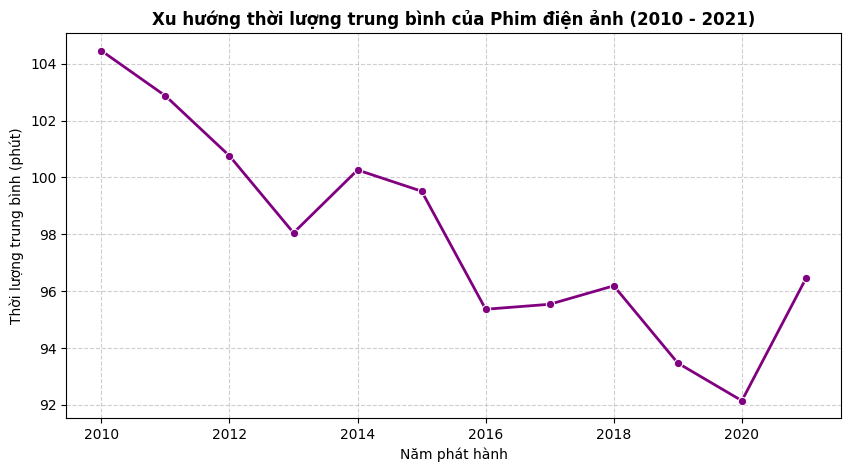

In [13]:
# Phan tich xu huong tieu thu noi dung
# 1. Loc du lieu tu nam 2010
recent_movie = movies_df[movies_df['release_year'] >=2010]
# 2. Tinh thoi luong trung binh
trend_duration = recent_movie.groupby('release_year')['duration_min'].mean().reset_index()
# 3.Ve bieu do
plt.figure(figsize=(10, 5))
sns.lineplot(data=trend_duration, x='release_year', y='duration_min', marker='o', color='purple', linewidth=2)

plt.title('Xu hướng thời lượng trung bình của Phim điện ảnh (2010 - 2021)', fontweight='bold')
plt.xlabel('Năm phát hành')
plt.ylabel('Thời lượng trung bình (phút)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

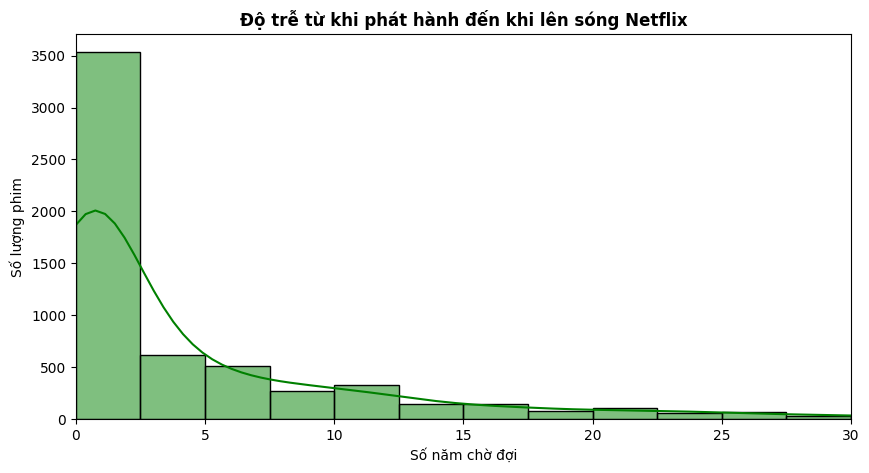

In [14]:
# Chien luoc thu mua va lam moi noi dung cua netflix
import warnings
warnings.filterwarnings('ignore') # Ẩn các cảnh báo lặt vặt

# 1. Chuyển đổi cột 'date_added' từ dạng chữ sang định dạng Thời gian chuẩn (Datetime)
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# 2. Tách lấy Năm thêm vào Netflix
df['year_added'] = df['date_added'].dt.year

# 3. Tính "Độ trễ" (Release Gap) = Năm thêm vào - Năm phát hành
df['release_gap'] = df['year_added'] - df['release_year']

# 4. Loại bỏ các dòng bị lỗi (độ trễ bị âm) và lọc lấy phim điện ảnh
gap_data = df[(df['type'] == 'Movie') & (df['release_gap'] >= 0)]

# 5. Vẽ biểu đồ phân bổ độ trễ
plt.figure(figsize=(10, 5))
sns.histplot(gap_data['release_gap'], bins=30, kde=True, color='green')

plt.title('Độ trễ từ khi phát hành đến khi lên sóng Netflix', fontweight='bold')
plt.xlabel('Số năm chờ đợi')
plt.ylabel('Số lượng phim')
plt.xlim(0, 30) # Chỉ xem giới hạn trễ tối đa 30 năm cho rõ
plt.show()